# Analyse des résultats — évaluations RAGAS

Charge les runs listés dans `RUNS` depuis `eval/results/`, produits par
`evaluate_ragas.py --label <label>`. Aucun run n'en écrase un autre.

| Run | Système évalué |
|---|---|
| `baseline` | prototype d'origine — texte libre, aucune validation |
| `validation_pydantic` | + validation Pydantic en entrée et en sortie : `RAGAnswer`, citations vérifiées, abstention |
| `tool_sql` | + tool SQL sur la base NBA, testset porté à 24 cas |
| `guardrails` | + validateur de couverture question ↔ schéma, et cadrage des sources dans le prompt |

Chaque run est analysé seul (sections 1 à 4), la comparaison est isolée en section 5.
Les cas hybrides et les tests de robustesse ont leurs propres sections (6 et 7).
Deux axes : les 4 métriques RAGAS jugées par gpt-4o, et le comportement d'abstention,
mesuré sans juge.

**Cas « bruitée »** : leur `reference_answer` est l'aveu d'une limite. Un score élevé
signifie que le système l'a reconnue ; un score bas, qu'il a répondu avec assurance à une
question sans réponse fiable.

## 0. Chargement et fonctions d'analyse

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path.cwd() / "results"
RUNS = ["baseline", "validation_pydantic", "tool_sql", "guardrails"]  # ordre chronologique
METRICS = ["faithfulness", "context_precision", "context_recall", "answer_correctness"]
ORDRE_CATEGORIES = ["simple", "complexe", "bruitee"]
N_PIRES_CAS = 6  # nombre de cas dont on affiche le texte complet, par run

# context_precision et context_recall ne jugent que les chunks FAISS. Depuis le tool
# SQL, elles ne mesurent plus tout le contexte du système, seulement sa branche
# vectorielle : renommées à l'affichage pour qu'on ne les lise pas comme globales.
# Les clés du JSON restent inchangées, pour rester comparables aux runs antérieurs.
NOMS_AFFICHES = {
    "context_precision": "vector_context_precision",
    "context_recall": "vector_context_recall",
}

# Un run absent est simplement ignoré : le notebook reste exécutable avant/après
# chaque nouvelle évaluation.
runs = {}
for label in RUNS:
    path = RESULTS_DIR / f"{label}.json"
    if path.exists():
        runs[label] = pd.DataFrame(json.loads(path.read_text(encoding="utf-8")))

print("Runs chargés :", ", ".join(runs) or "aucun")
print("Runs absents :", ", ".join(r for r in RUNS if r not in runs) or "aucun")

Runs chargés : baseline, validation_pydantic, tool_sql
Runs absents : aucun


In [2]:
def analyser_abstention(d):
    """Axe comportemental : le système reconnaît-il qu'il ne peut pas répondre ?

    Mesure déterministe, sans juge LLM : croise le champ `abstain` (sortie structurée
    RAGAnswer) avec `expected_behavior` du testset. `expected_behavior` ne sert qu'ici,
    jamais à recalculer un score RAGAS.
    """
    if "abstain" not in d.columns:
        print("Axe non applicable : ce run précède la sortie structurée RAGAnswer.")
        return

    # Les cas en échec (ex. erreur 429 côté juge) n'ont ni abstain ni expected_behavior.
    # Les garder les compterait à tort comme des abstentions correctes, car bool(NaN) vaut True.
    c = d.dropna(subset=["abstain"])[
        ["id", "categorie", "expected_behavior", "abstain", "abstain_reason"]
    ].copy()
    exclus = len(d) - len(c)
    if exclus:
        print(f"{exclus} cas exclus (en échec, sans sortie structurée)")

    # astype(bool) : dès qu'un cas est en échec la colonne devient de type object, et
    # les opérations booléennes de pandas y deviennent binaires (~True donne -2)
    c["abstain"] = c["abstain"].astype(bool)
    # Seuls abstain_absence et abstain_ambiguous appellent une abstention. flag_anomaly
    # (B3 : l'en-tête 15:00) et flag_limitation (B6 : exhaustivité du retrieval) attendent
    # au contraire une RÉPONSE qui signale la limite — les compter comme des abstentions
    # attendues pénalisait à tort les deux runs.
    # Ce que cet axe ne mesure pas : si le signalement a bien eu lieu. Seul le fait de
    # répondre est vérifiable de façon déterministe.
    ABSTENTION_ATTENDUE = {"abstain_absence", "abstain_ambiguous"}
    c["devait_s_abstenir"] = c["expected_behavior"].isin(ABSTENTION_ATTENDUE)

    def classer(row):
        if row["devait_s_abstenir"]:
            return "abstention correcte" if row["abstain"] else "non-détection (répond quand même)"
        return "faux refus" if row["abstain"] else "réponse correcte"

    c["resultat"] = c.apply(classer, axis=1)

    # abstention_accuracy = part des cas où le comportement correspond à l'attendu
    ok = c["resultat"].isin(["abstention correcte", "réponse correcte"]).sum()
    print(f"abstention_accuracy : {ok}/{len(c)} = {ok / len(c):.1%}\n")
    print(c["resultat"].value_counts().to_string())
    display(c[["id", "categorie", "expected_behavior", "abstain", "resultat", "abstain_reason"]])


def analyser(label):
    """Analyse complète et autonome d'un run : scores globaux, par catégorie, par
    modalité, comportement d'abstention, puis texte des cas les plus faibles."""
    if label not in runs:
        print(f"Run '{label}' absent de results/ — rien à analyser pour l'instant.")
        return

    d = runs[label]
    manquants = d[METRICS].isna().any(axis=1).sum()
    print(f"===== Run '{label}' : {len(d)} cas, {manquants} avec des scores manquants =====\n")

    print("--- Scores moyens globaux ---")
    display(d[METRICS].mean().round(3).to_frame(label).T)

    par_cat = d.groupby("categorie")[METRICS].mean().round(3).reindex(ORDRE_CATEGORIES)
    par_mod = d.groupby("modalite")[METRICS].mean().round(3)
    print("--- Par catégorie ---")
    display(par_cat)
    print("--- Par modalité ---")
    display(par_mod)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    par_cat.plot(kind="bar", ax=axes[0], rot=0, legend=False)
    axes[0].set_title(f"{label} — par catégorie")
    par_mod.plot(kind="bar", ax=axes[1], rot=0, legend=False)
    axes[1].set_title(f"{label} — par modalité")
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")
    axes[0].set_ylabel("Score moyen (0-1)")
    handles, noms = axes[0].get_legend_handles_labels()
    fig.legend(handles, noms, title="Métrique", loc="upper right")
    plt.tight_layout()
    plt.show()

    print("--- Comportement d'abstention ---")
    analyser_abstention(d)

    print(f"--- Les {N_PIRES_CAS} cas les plus faibles (faithfulness) ---\n")
    for _, row in d.nsmallest(N_PIRES_CAS, "faithfulness").iterrows():
        print(f"=== {row['id']} ({row['categorie']} / {row['modalite']}) ===")
        print(
            f"faithfulness={row['faithfulness']:.2f}  context_precision={row['context_precision']:.2f}  "
            f"context_recall={row['context_recall']:.2f}  answer_correctness={row['answer_correctness']:.2f}"
        )
        print(f"\nQuestion : {row['question']}")
        print(f"\nRéponse de référence : {row['reference_answer']}")
        print(f"\nRéponse du système : {row['system_response']}")
        print("\n" + "-" * 100 + "\n")

def analyser_routage(label):
    """Quelle chaîne le système a-t-il RÉELLEMENT empruntée pour chaque question ?

    Mesure déterministe, sans juge LLM : `sql_queries` et `citations` sont relevés
    dans le code à partir de la trace d'exécution, jamais déclarés par le modèle
    (cf. schemas.py). RAGAS ne peut pas dire si un cas hybride a traversé les deux
    chaînes ; ces deux champs, si.
    """
    if label not in runs or "sql_queries" not in runs[label].columns:
        print("Axe non applicable : ce run précède le tool SQL.")
        return

    d = runs[label].copy()
    d["a_sql"] = d["sql_queries"].apply(lambda x: bool(x) if isinstance(x, list) else False)
    d["a_vectoriel"] = d["citations"].apply(lambda x: bool(x) if isinstance(x, list) else False)

    def route(r):
        if r["a_sql"] and r["a_vectoriel"]:
            return "les deux"
        if r["a_sql"]:
            return "SQL seul"
        if r["a_vectoriel"]:
            return "vectoriel seul"
        return "aucune preuve"

    d["route"] = d.apply(route, axis=1)

    print("Chaînes empruntées, par modalité attendue :")
    display(pd.crosstab(d["modalite"], d["route"]))

    # Les cas hybrides sont ceux pour lesquels on ATTEND les deux chaînes
    hyb = d[d["modalite"] == "hybride"]
    if len(hyb):
        deux = (hyb["route"] == "les deux").sum()
        print(f"\nCas hybrides ayant réellement traversé les deux chaînes : {deux}/{len(hyb)}")
    display(d[["id", "modalite", "a_sql", "a_vectoriel", "route"]])


## 1. Run `baseline` — prototype d'origine

===== Run 'baseline' : 18 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
baseline,0.335,0.262,0.528,0.234


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.461,0.308,0.500,0.343
complexe,0.414,0.312,0.500,0.208
bruitee,0.129,0.167,0.583,0.152


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.275,0.050,0.222,0.217
pdf_reddit,0.394,0.475,0.833,0.252


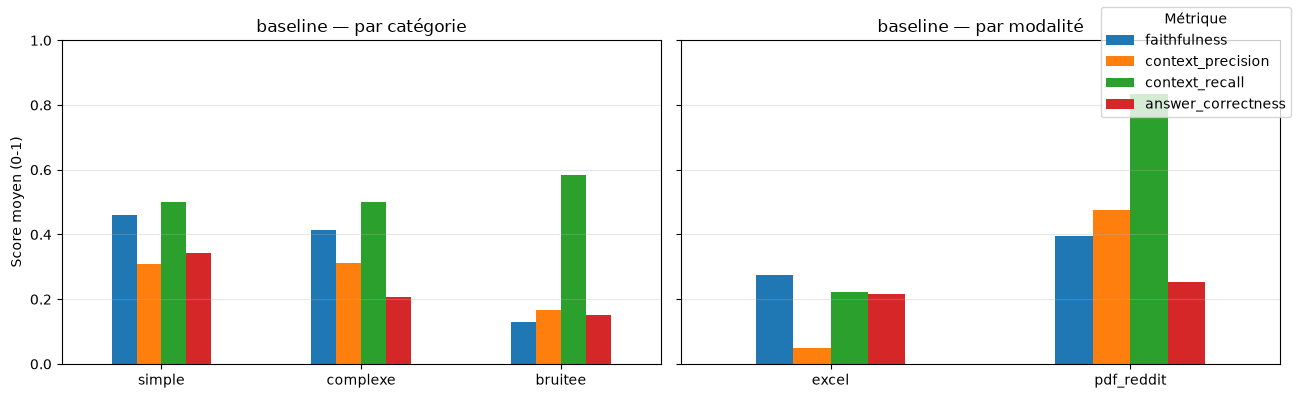

--- Comportement d'abstention ---
Axe non applicable : ce run précède la sortie structurée RAGAnswer.
--- Les 6 cas les plus faibles (faithfulness) ---

=== C1 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.13

Question : Quel joueur a le meilleur pourcentage de réussite à 3 points (3P%) parmi ceux ayant tenté plus de 300 tirs à 3 points cette saison ?

Réponse de référence : Zach LaVine, 44,6% sur 533 tentatives (3PA).

Réponse du système : D'après les données disponibles, voici l'analyse pour identifier le joueur avec le meilleur **3P%** parmi ceux ayant tenté **plus de 300 tirs à 3 points (3PA)** cette saison :

### **Top 5 des joueurs éligibles (3PA > 300) :**
*(Classés par 3P% décroissant)*

| **Joueur**               | **Équipe** | **3PA** | **3P%** | **PTS** | **FGM** | **FG%** |
|--------------------------|------------|---------|---------|---------|---------|---------|
| **Tyrese Haliburton**    | IND        | 320    

In [3]:
analyser("baseline")

## 2. Run `validation_pydantic` — couche de validation Pydantic

===== Run 'validation_pydantic' : 18 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
validation_pydantic,0.806,0.269,0.583,0.296


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.703,0.308,0.667,0.316
complexe,0.924,0.275,0.500,0.261
bruitee,0.792,0.222,0.583,0.311


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.727,0.087,0.333,0.250
pdf_reddit,0.886,0.450,0.833,0.342


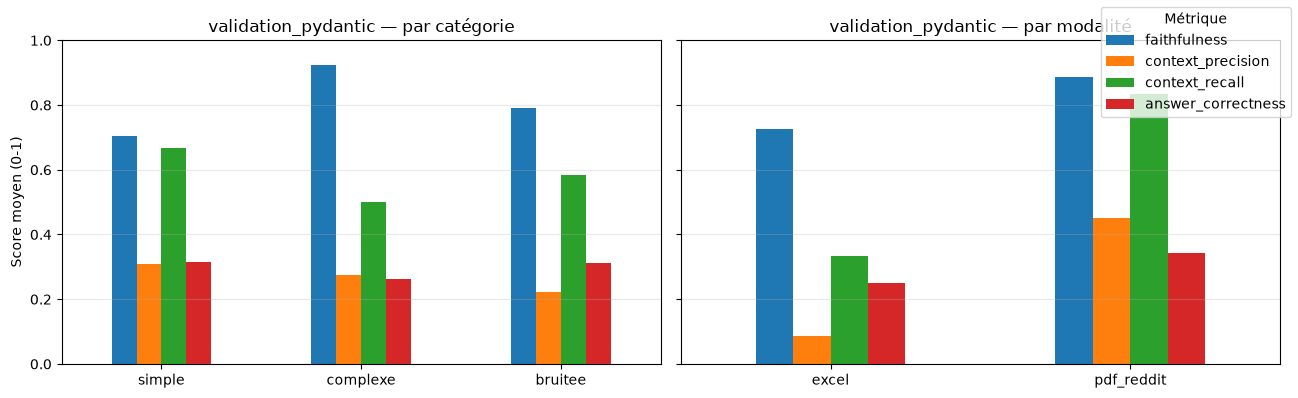

--- Comportement d'abstention ---
abstention_accuracy : 14/18 = 77.8%

resultat
réponse correcte                     11
faux refus                            3
abstention correcte                   3
non-détection (répond quand même)     1


,id,categorie,expected_behavior,abstain,resultat,abstain_reason
0,S1,simple,answer,True,faux refus,Donnée absente : le nom de Nikola Jokić n'appa...
1,S2,simple,answer,False,réponse correcte,None
2,S3,simple,answer,False,réponse correcte,None
3,S4,simple,answer,True,faux refus,"Aucune mention d'un ""young wing duo"" ou de jou..."
4,S5,simple,answer,False,réponse correcte,None
5,S6,simple,answer,False,réponse correcte,None
6,C1,complexe,answer,True,faux refus,Les données ne fournissent pas suffisamment d'...
7,C2,complexe,answer,False,réponse correcte,None
8,C3,complexe,answer,False,réponse correcte,None
9,C4,complexe,answer,False,réponse correcte,None


--- Les 6 cas les plus faibles (faithfulness) ---

=== S3 (simple / excel) ===
faithfulness=0.25  context_precision=0.20  context_recall=0.00  answer_correctness=0.11

Question : Combien de matchs Shai Gilgeous-Alexander a-t-il joués cette saison ?

Réponse de référence : 76 matchs (colonne GP).

Réponse du système : Shai Gilgeous-Alexander a joué **2485 matchs** cette saison. Cette information est basée sur le total de points marqués (2485), qui correspond au nombre total de matchs joués dans le contexte fourni.

----------------------------------------------------------------------------------------------------

=== S2 (simple / excel) ===
faithfulness=0.50  context_precision=0.25  context_recall=1.00  answer_correctness=0.27

Question : Quel est le pourcentage de réussite aux lancers francs de Stephen Curry ?

Réponse de référence : 93,3% (colonne FT%).

Réponse du système : Le pourcentage de réussite aux lancers francs (FT%) de Stephen Curry n'est pas directement disponible dans le

In [4]:
analyser("validation_pydantic")

## 3. Run `tool_sql` — agent équipé du tool SQL

Testset porté à **24 cas**, dont 6 de modalité `hybride` qui exigent de croiser Reddit et
la base.

Pour les **14 cas où l'agent a interrogé la base**, la faithfulness est jugée sur un
contexte élargi aux requêtes SQL et à leurs résultats ; les 10 autres gardent les chunks
seuls, comme les métriques de récupération.

===== Run 'tool_sql' : 24 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
tool_sql,0.692,0.19,0.479,0.408


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.825,0.231,0.500,0.515
complexe,0.662,0.213,0.375,0.459
bruitee,0.589,0.125,0.562,0.249


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.541,0.050,0.333,0.506
hybride,0.744,0.000,0.167,0.456
pdf_reddit,0.809,0.456,0.833,0.277


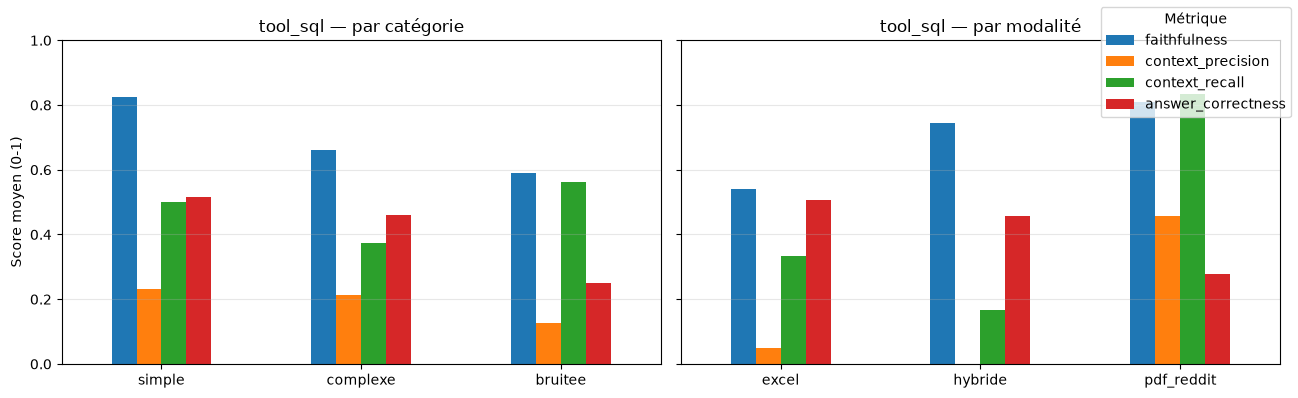

--- Comportement d'abstention ---
abstention_accuracy : 19/24 = 79.2%

resultat
réponse correcte                     17
non-détection (répond quand même)     4
abstention correcte                   2
faux refus                            1


,id,categorie,expected_behavior,abstain,resultat,abstain_reason
0,S1,simple,answer,False,réponse correcte,None
1,S2,simple,answer,False,réponse correcte,None
2,S3,simple,answer,False,réponse correcte,None
3,S4,simple,answer,True,faux refus,Les chunks disponibles ne contiennent aucune m...
4,S5,simple,answer,False,réponse correcte,None
5,S6,simple,answer,False,réponse correcte,None
6,C1,complexe,answer,False,réponse correcte,None
7,C2,complexe,answer,False,réponse correcte,None
8,C3,complexe,answer,False,réponse correcte,None
9,C4,complexe,answer,False,réponse correcte,None


--- Les 6 cas les plus faibles (faithfulness) ---

=== S3 (simple / excel) ===
faithfulness=0.00  context_precision=0.20  context_recall=0.00  answer_correctness=0.62

Question : Combien de matchs Shai Gilgeous-Alexander a-t-il joués cette saison ?

Réponse de référence : 76 matchs (colonne GP).

Réponse du système : Shai Gilgeous-Alexander a joué **76 matchs** cette saison (2024-25).

----------------------------------------------------------------------------------------------------

=== B3 (bruitee / excel) ===
faithfulness=0.12  context_precision=0.00  context_recall=0.00  answer_correctness=0.15

Question : Que représente réellement la colonne affichée "15:00" (ou "15:00:00") située entre FG% et 3PA dans le fichier de données ?

Réponse de référence : Il s'agit très probablement de la colonne 3PM (tirs à 3 points réussis), dont le nom a été mal interprété par Excel comme l'horaire "3 PM" puis affiché 15:00. Ce n'est pas une vraie donnée temporelle.

Réponse du système : La colonne

In [5]:
analyser("tool_sql")

### Routage entre les deux chaînes

Une requête enregistrée prouve que la base a été interrogée, une citation validée qu'un
chunk a été utilisé — ce que les métriques RAGAS ne disent pas.

In [6]:
analyser_routage("tool_sql")

Chaînes empruntées, par modalité attendue :


route,SQL seul,aucune preuve,les deux,vectoriel seul
modalite,,,,
excel,2,0,6,1
hybride,2,0,4,0
pdf_reddit,0,2,0,7



Cas hybrides ayant réellement traversé les deux chaînes : 4/6


,id,modalite,a_sql,a_vectoriel,route
0,S1,excel,True,False,SQL seul
1,S2,excel,True,True,les deux
2,S3,excel,True,True,les deux
3,S4,pdf_reddit,False,False,aucune preuve
4,S5,pdf_reddit,False,True,vectoriel seul
5,S6,pdf_reddit,False,True,vectoriel seul
6,C1,excel,True,True,les deux
7,C2,excel,True,True,les deux
8,C3,excel,True,False,SQL seul
9,C4,pdf_reddit,False,True,vectoriel seul


## 4. Run `guardrails` — validateur de couverture et cadrage des sources

Deux mécanismes ajoutés **en même temps**, sur le même testset de 24 cas :

- un **validateur de couverture** — un premier agent décrit ce que la question demande à la
  base, le code confronte cette intention au schéma, et **retire le tool SQL** quand une
  dimension demandée est absente. C'est le contrôle en code annoncé en conclusion du run
  précédent ;
- un **cadrage des sources dans le prompt** — la réponse ne doit sortir ni des chunks
  récupérés ni des résultats SQL, et un chiffre valable pour un périmètre ne vaut pas pour
  un autre. La ligne annonçant la base disparaît du prompt quand le tool a été retiré.

**Leurs effets ne sont pas isolés** : l'écart avec `tool_sql` les mesure ensemble. Le
validateur a en revanche été mesuré seul, hors RAGAS — 22/24 sur le testset et 8/8 sur des
formulations inédites (`tests/test_compatibilite.py`).


In [ ]:
analyser("guardrails")

### Routage — une abstention n'a pas de provenance

Les cas « aucune preuve » passent de 2 à 6. Ce n'est pas une perte de traçabilité : **les
six sont des abstentions**, et une abstention ne cite rien puisqu'elle ne s'appuie sur rien.
Trois d'entre elles — B1, B2, M6 — sont exactement les cas pour lesquels le validateur a
été construit.


In [ ]:
analyser_routage("guardrails")

## 5. Comparaison des runs

**Seule mesure de progression valide** : restreinte aux cas notés dans les quatre runs.
Les 6 cas hybrides, ajoutés à cette étape, en sont exclus par construction (section 6).

`context_precision` et `context_recall` sont affichées sous les noms `vector_*` : elles
ne jugent que les chunks FAISS, et c'est ce qui les garde comparables d'un run à l'autre.

Comparaison sur 18 cas communs aux 3 runs
  absents d'au moins un testset : M1, M2, M3, M4, M5, M6

Effectifs par catégorie :
categorie
simple      6
complexe    6
bruitee     6

--- Scores moyens par run ---


,faithfulness,vector_context_precision,vector_context_recall,answer_correctness
run,,,,
baseline,0.335,0.262,0.528,0.234
validation_pydantic,0.806,0.269,0.583,0.296
tool_sql,0.675,0.253,0.583,0.391
ecart (dernier - premier),0.340,-0.009,0.055,0.157


--- answer_correctness par catégorie ---


run,baseline,validation_pydantic,tool_sql
categorie,,,
simple,0.343,0.316,0.449
complexe,0.208,0.261,0.535
bruitee,0.152,0.311,0.191


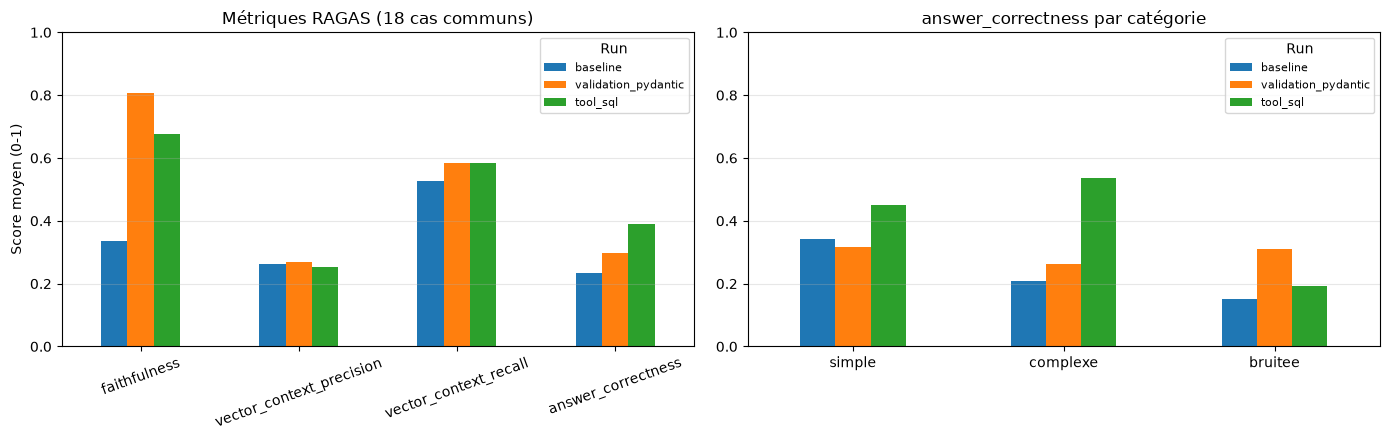

In [7]:
dispo = [r for r in RUNS if r in runs]

if len(dispo) < 2:
    print("Comparaison impossible : il faut au moins deux runs dans results/.")
else:
    df_all = pd.concat([runs[r].assign(run=r) for r in dispo], ignore_index=True)
    notes = df_all.dropna(subset=METRICS)
    cas_communs = set.intersection(*(set(notes.loc[notes["run"] == r, "id"]) for r in dispo))

    # Deux raisons distinctes d'être hors comparaison, à ne surtout pas confondre :
    # un cas ajouté au testset après coup n'est pas un échec de mesure.
    presents = {r: set(runs[r]["id"]) for r in dispo}
    absents = {i for i in set(df_all["id"]) if any(i not in presents[r] for r in dispo)}
    echecs = set(df_all["id"]) - cas_communs - absents

    print(f"Comparaison sur {len(cas_communs)} cas communs aux {len(dispo)} runs")
    if absents:
        print(f"  absents d'au moins un testset : {', '.join(sorted(absents))}")
    if echecs:
        print(f"  non notés (échec du juge)     : {', '.join(sorted(echecs))}")

    comparaison = notes[notes["id"].isin(cas_communs)]

    # Effectifs par catégorie : sans eux, une catégorie peut sembler meilleure
    # simplement parce qu'un cas y manque.
    print("\nEffectifs par catégorie :")
    print(comparaison[comparaison["run"] == dispo[0]]["categorie"].value_counts().to_string())

    tableau = comparaison.groupby("run")[METRICS].mean().reindex(dispo).round(3)
    tableau = tableau.rename(columns=NOMS_AFFICHES)
    tableau.loc["ecart (dernier - premier)"] = (tableau.iloc[-1] - tableau.iloc[0]).round(3)
    print("\n--- Scores moyens par run ---")
    display(tableau)

    print("--- answer_correctness par catégorie ---")
    par_cat = (
        comparaison.pivot_table(index="categorie", columns="run", values="answer_correctness")
        .reindex(ORDRE_CATEGORIES)[dispo]
        .round(3)
    )
    display(par_cat)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    tableau.drop(index="ecart (dernier - premier)").T.plot(kind="bar", ax=axes[0], rot=20)
    axes[0].set_title(f"Métriques RAGAS ({len(cas_communs)} cas communs)")
    axes[0].set_ylabel("Score moyen (0-1)")
    par_cat.plot(kind="bar", ax=axes[1], rot=0)
    axes[1].set_title("answer_correctness par catégorie")
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")
        ax.legend(title="Run", fontsize=8)
    plt.tight_layout()
    plt.show()

### `tool_sql` → `guardrails` : les 24 cas, sans restriction

Ces deux runs partagent le même testset : la comparaison peut porter sur les 24 cas, les
6 hybrides compris — ce que la restriction aux cas communs aux quatre runs interdit.

**M1 en est exclue.** Sa formulation a été raccourcie entre les deux runs, et ce
raccourcissement a supprimé l'ancrage qui plaçait le bon chunk dans le top-5 : dans
`guardrails`, le commentaire citant « Cade » n'est plus récupéré, et le système répond
Jaden Ivey. Sa chute mesure un effet du testset, pas un effet des garde-fous.

**Plancher de bruit du juge.** Le contexte récupéré est *identique* dans `baseline`,
`tool_sql` et `guardrails` (18/18 cas), la recherche vectorielle n'ayant jamais été
modifiée. Pourtant `context_recall` y vaut 0.528 contre 0.583. Même entrée, score
différent : c'est la variance de gpt-4o. En dessous de **±0.05 environ**, un écart ne doit
pas être interprété.


In [ ]:
# Même testset : comparaison sur tous les cas, hybrides compris.
# M1 exclue — sa question a changé entre les deux runs (cf. markdown ci-dessus).
PAIRE = ["tool_sql", "guardrails"]
BRUIT_DU_JUGE = 0.05  # mesuré sur un contexte récupéré identique d'un run à l'autre

if all(r in runs for r in PAIRE):
    ids = set(runs["tool_sql"]["id"]) & set(runs["guardrails"]["id"]) - {"M1"}
    direct = pd.DataFrame(
        {r: runs[r][runs[r]["id"].isin(ids)][METRICS].mean() for r in PAIRE}
    ).round(3)
    direct["écart"] = (direct["guardrails"] - direct["tool_sql"]).round(3)
    direct["interprétable"] = direct["écart"].abs() > BRUIT_DU_JUGE
    print(f"--- {len(ids)} cas (M1 exclue) ---")
    display(direct.rename(index=NOMS_AFFICHES))

    # L'abstention est mesurée sans juge : c'est le seul axe insensible à cette variance
    ATTENDUE = {"abstain_absence", "abstain_ambiguous"}
    lignes = []
    for r in PAIRE:
        d = runs[r].dropna(subset=["abstain"]).copy()
        d["abstain"] = d["abstain"].astype(bool)
        devait = d["expected_behavior"].isin(ATTENDUE)
        juste = (devait & d["abstain"]) | (~devait & ~d["abstain"])
        lignes.append({
            "run": r,
            "abstention_accuracy": f"{juste.sum()}/{len(d)} = {juste.mean():.1%}",
            "faux refus": ", ".join(sorted(d.loc[~devait & d["abstain"], "id"])) or "—",
            "non-détections": ", ".join(sorted(d.loc[devait & ~d["abstain"], "id"])) or "—",
        })
    print("--- Comportement d'abstention (déterministe, sans juge) ---")
    display(pd.DataFrame(lignes).set_index("run"))

    # Les cas qui ont le plus bougé : c'est là que se lit ce que le mécanisme a fait
    a, b = (runs[r].set_index("id") for r in PAIRE)
    mouvement = pd.DataFrame({
        "correctness_avant": a["answer_correctness"], "correctness_après": b["answer_correctness"],
        "faithfulness_avant": a["faithfulness"], "faithfulness_après": b["faithfulness"],
        "abstient_avant": a["abstain"], "abstient_après": b["abstain"],
    }).round(3)
    mouvement["écart"] = (mouvement["correctness_après"] - mouvement["correctness_avant"]).round(3)
    print("--- Les 8 cas qui ont le plus bougé ---")
    display(mouvement.reindex(mouvement["écart"].abs().sort_values(ascending=False).index).head(8))

## 6. Les cas hybrides

Ces 6 cas n'existaient pas avant `tool_sql` : **aucune progression n'est mesurable depuis
la baseline**, seulement une couverture. Ils exigent les deux sources — Reddit pour
identifier l'entité, la base pour le chiffre.

Entre `tool_sql` et `guardrails`, en revanche, la comparaison est directe. M1 mise à part,
dont la question a changé.


In [8]:
RECENT = "guardrails" if "guardrails" in runs else "tool_sql"
hybrides = runs[RECENT].query("modalite == 'hybride'") if RECENT in runs else None

if hybrides is None or not len(hybrides):
    print("Aucun cas hybride dans les runs chargés.")
else:
    # Les deux runs côte à côte : c'est le seul endroit où les 6 cas sont comparables
    if "tool_sql" in runs and "guardrails" in runs:
        a, b = (runs[r].set_index("id") for r in ("tool_sql", "guardrails"))
        ids = [i for i in hybrides["id"]]
        cote = pd.DataFrame({
            "correctness_tool_sql": a.loc[ids, "answer_correctness"],
            "correctness_guardrails": b.loc[ids, "answer_correctness"],
            "abstient_tool_sql": a.loc[ids, "abstain"],
            "abstient_guardrails": b.loc[ids, "abstain"],
            "attendu": b.loc[ids, "expected_behavior"],
        }).round(3)
        print("--- Les 6 hybrides, avant et après les garde-fous ---")
        display(cote)

    colonnes = ["id", "categorie", "expected_behavior", "abstain"] + METRICS
    print(f"--- Détail du run '{RECENT}' ---")
    display(hybrides[colonnes].set_index("id").round(3))

    for _, row in hybrides.iterrows():
        print(f"=== {row['id']} ({row['categorie']}) — attendu : {row['expected_behavior']} ===")
        print(f"Question  : {row['question']}")
        print(f"Référence : {row['reference_answer']}")
        print(f"Réponse   : {row['system_response'][:400]}")
        for requete in (row["sql_queries"] or []):
            print(f"SQL       : {' '.join(requete.split())[:150]}")
        print("-" * 100)

,categorie,expected_behavior,abstain,faithfulness,context_precision,context_recall,answer_correctness
id,,,,,,,
M1,simple,answer,False,1.000,0.0,0.0,0.809
M2,simple,answer,False,0.800,0.0,0.0,0.619
M3,complexe,answer,False,0.750,0.0,0.0,0.337
M4,complexe,answer,False,0.417,0.0,0.0,0.124
M5,bruitee,abstain_absence,True,1.000,0.0,1.0,0.776
M6,bruitee,abstain_absence,False,0.500,0.0,0.0,0.071


=== M1 (simple) — attendu : answer ===
Question  : Dans le fil sur les équipes qui ont impressionné en playoffs, quel joueur des Pistons est salué pour son leadership ? Combien de points a-t-il marqués en saison régulière, et sur combien de matchs ?
Référence : Cade Cunningham : 1827 points en 70 matchs.
Réponse   : Le joueur des Pistons salué pour son leadership dans le fil Reddit est **Cade Cunningham**. Il a marqué **1827 points** en saison régulière sur **70 matchs**.
SQL       : SELECT p.full_name, s.pts_total, s.games_played FROM stats s JOIN players p USING (player_id) WHERE p.full_name = 'Cade Cunningham';
----------------------------------------------------------------------------------------------------
=== M2 (simple) — attendu : answer ===
Question  : Un commentaire affirme que Jalen Brunson a tourné à 31 points par match en finale de conférence Est. Ce chiffre correspond-il à sa moyenne dans les données ?
Référence : Non : 26,0 points par match en saison régulière (1690 po

## 7. Tests de robustesse

Les 8 cas `bruitée` sont des **stress tests délibérés**, chacun visant un mode de défaillance
distinct. Leur classification vit dans `eval/testset.json` : `sous_type` (la famille),
`evaluation_focus` (le mécanisme) et `note` (pourquoi le cas existe).

Le produit doit **animer le débat entre fans** à partir de données que SportSee vend : c'est ce
qui fait de chaque famille un risque, et ce qui justifie de la tester.

| Famille | Cas | Ce qu'elle éprouve | Risque pour SportSee | Résultat |
|---|---|---|---|---|
| `absence_info` | B1, B2, B4, M5, M6 | la donnée n'existe pas — grain absent (B1), dimension absente (B2), corpus muet (B4), entité omniprésente dans les fils mais absente de la base (M5), périmètre playoffs (M6) | un chiffre inventé qu'un fan citera comme un fait, alors que SportSee vend de la donnée | **5/5 s'abstiennent** ✅ |
| `premisse_trompeuse` | B3 | la question suppose une vraie colonne temporelle, née d'un bug d'autoformat Excel | l'assistant valide une erreur du fichier source et la propage | répond, mais **fabrique** ❌ |
| `ambiguite` | B5 | « objectivement » appliqué à une opinion sans consensus | l'assistant **tranche** le débat au lieu de l'**animer** | s'abstient ✅ |
| `limite_retrieval` | B6 | exhaustivité sur un fil de 15 pages, hors de portée d'un top-k | une exhaustivité affirmée sans fondement, indétectable par le lecteur | répond, mais **fabrique** ❌ |

**Sur l'axe comportemental : 8/8.** Mais B3 et B6 attendent `flag_anomaly` et `flag_limitation`,
c'est-à-dire une réponse **qui signale la limite**. L'axe ne vérifie que le fait de répondre : il
les compte donc justes. Leurs scores disent l'inverse — B3 : 0.15 → 0.14, B6 : 0.03 → 0.03 — et
la lecture des réponses est plus sévère encore :

> **B3** — « la colonne représente les minutes jouées après 15:00 de jeu […] pendant la période
> où le score est serré » : une définition entièrement inventée pour une colonne corrompue.
>
> **B6** — « les équipes les plus citées sont les Magic d'Orlando et les Rockets de Houston » :
> un classement présenté comme exhaustif, établi sur 5 chunks d'un fil de 15 pages.

**Deux familles sur quatre restent ouvertes**, et ce sont celles où l'erreur est invisible pour
l'utilisateur : la réponse est fluide, plausible, et rien ne signale qu'elle est fabriquée. Le
validateur agit sur les dimensions absentes du schéma — pas sur une prémisse fausse, pas sur une
limite architecturale du retrieval.


## 8. Conclusion

Sur les **18 cas** communs aux quatre runs. Les 6 hybrides sont traités en section 6.

| Métrique | baseline | validation_pydantic | tool_sql | guardrails | écart total |
|---|---|---|---|---|---|
| answer_correctness | 0.234 | 0.296 | 0.391 | **0.511** | **+0.277** |
| faithfulness | 0.335 | 0.806 | 0.675 | **0.864** | **+0.529** |
| vector_context_precision | 0.262 | 0.269 | 0.253 | 0.269 | +0.007 |
| vector_context_recall | 0.528 | 0.583 | 0.583 | 0.583 | +0.055 |

Les deux dernières lignes ne mesurent aucun effet du système : la recherche vectorielle n'a
jamais été modifiée, et le contexte récupéré est **identique** dans `baseline`, `tool_sql` et
`guardrails` (18/18 cas). Le +0.007 de precision est négligeable ; le +0.055 de recall est
précisément ce qui sert à chiffrer la variance du juge en section 5 — même entrée, score
différent.

| `answer_correctness` | baseline | pydantic | tool_sql | guardrails | apport SQL | apport garde-fous |
|---|---|---|---|---|---|---|
| bruitée | 0.152 | 0.311 | 0.191 | 0.409 | −0.120 | **+0.218** |
| complexe | 0.208 | 0.261 | 0.535 | 0.616 | **+0.274** | +0.081 |
| simple | 0.343 | 0.316 | 0.449 | 0.507 | +0.133 | +0.058 |

### Ce que chaque étape a apporté

- **Pydantic** introduit l'abstention, absente du prototype : faithfulness 0.335 → 0.806.
  Mais elle sert **3 fois à tort** (S1, S4, C1), d'où le recul des simples (−0.027).
- **Le tool SQL** calcule sur l'ensemble des données au lieu de 5 chunks : complexe
  **+0.274**, C1 passe de 0.133 à 0.701. L'échange est symétrique — 2 faux refus
  deviennent de bonnes réponses, 2 abstentions justifiées deviennent des fabrications
  (B1 0.74 → 0.27, B2 0.42 → 0.07).
- **Les garde-fous** corrigent précisément cela : B1, B2 et M6 s'abstiennent, faithfulness
  portée à 1.00, correctness +0.42 à +0.54. `abstention_accuracy` **19/24 → 22/24**, et
  **plus aucune non-détection** : toutes les erreurs restantes sont des faux refus, le côté
  où l'erreur se voit.
- **Leur coût tient en un cas** : M2, où la compétition *citée* est prise pour la
  compétition *demandée*. Limite connue avant le run, déclarée `xfail` dans
  `tests/test_compatibilite.py` ; elle s'est matérialisée telle quelle.
- **La sur-abstention redoutée n'a pas eu lieu** : les seuls faux refus sont S4 et M2.
  B4 et B5 s'abstiennent à juste titre — c'est ce que leur `expected_behavior` demande — et
  C4 comme C6 répondent. La catégorie bruitée, celle qui portait les échecs visés, gagne
  **+0.218**.

### Le fil conducteur

Le danger n'est pas que le SQL échoue, c'est **qu'il réussisse sur une question mal posée**.
B2 inventait une partition domicile/extérieur, M6 donnait un total de saison pour une série
de playoffs, B1 la saison entière pour « les 5 derniers matchs » : trois requêtes valides.
La description du tool avertissait pourtant de ces absences — **une consigne dans le prompt
ne contraint rien**. Il fallait un contrôle en code, hors du modèle, comme l'autoriseur
SQLite refuse les écritures sans jamais consulter le modèle.

### Biais et limites

Trois familles à ne pas confondre : ce que cette évaluation **ne peut pas établir**, ce que
l'architecture **ne sait pas faire**, et ce qui **n'a pas été mesuré du tout**. Les cas cités
sont les indices qui ont révélé chaque limite, pas la limite elle-même.

**1. Ce que l'évaluation ne peut pas établir**

| Limite | Pourquoi | Piste |
|---|---|---|
| Le testset a servi au réglage | 24 cas, sur lesquels le prompt d'intention et le registre ont été ajustés : c'est un jeu de **développement**, pas un jeu de test indépendant. Un score obtenu dessus majore la performance attendue | constituer un jeu tenu à l'écart, jamais consulté pendant le développement |
| Une seule exécution par système | aucun intervalle de confiance. La variance du juge seule vaut **±0.05** (mesurée en section 5 sur un contexte identique) | répéter chaque run, publier un écart-type |
| Un seul juge, jamais confronté à l'humain | les métriques héritent des biais de gpt-4o sans qu'on sache lesquels | accord inter-juges sur un échantillon annoté à la main |
| Deux mécanismes changés ensemble | l'écart `tool_sql` → `guardrails` ne se répartit pas entre validateur et prompt | un run par mécanisme |
| Le contexte de preuve varie entre runs | la faithfulness ne compare pas des générateurs à contexte égal | figer le contexte jugé, ou ne comparer que des systèmes à contexte identique |
| Un score isolé induit en erreur | M6 affichait faithfulness 0.50 et correctness 0.07 : fidèle à un contexte hors sujet | lire les métriques ensemble, et avec le comportement d'abstention |

**2. Ce que l'architecture ne sait pas faire**

| Limite | Indice | Conséquence en production | Piste |
|---|---|---|---|
| Récupération à `k` fixe, sans seuil ni reclassement | M1, B6 | une reformulation anodine change la réponse ; un document entier ne peut pas être parcouru | seuil de similarité, reclassement par cross-encoder, parcours par lots |
| Aucune vérification des entités envoyées au SQL | M1, M4 | une erreur d'identification en amont produit une requête **correcte sur la mauvaise entité** : elle se propage sans aucun signal | exiger qu'une entité requêtée soit justifiée par un chunk cité |
| Le garde-fou repose lui-même sur un LLM | M2 | son mode d'échec est le faux refus, silencieux pour l'utilisateur | journaliser chaque refus, suivre son taux d'erreur en continu |
| Le registre ne couvre que les dimensions déclarées | — | une dimension absente du registre passe comme avant : le mécanisme ne protège que de ce qu'on a su nommer | étendre le vocabulaire à mesure que des cas remontent des journaux |
| Périmètre des données : une saison, saison régulière, aucune granularité fine | B1, B2, M6 | une part des questions légitimes est **intrinsèquement sans réponse** | seconde source : calendrier, box scores |
| La même source arrive par deux chemins | B3 | le fichier est à la fois vectorisé et interrogeable ; sa version en chunks est une représentation dégradée d'un tableau | donner la préséance à la base pour tout chiffre — fait dans ce run, non isolé |

**3. Ce qui n'a pas été mesuré**

- **Robustesse aux formulations** : aucune paraphrase, faute de frappe ni question hors
  domaine dans le testset. M1 suggère que la sensibilité est réelle.
- **Injection de prompt** : le corpus est du texte d'utilisateurs Reddit, injecté tel quel
  dans le prompt. Aucun test ne vérifie qu'un commentaire ne peut pas détourner l'agent.
- **Latence et coût** par question : l'extraction d'intention ajoute un appel de modèle
  avant même la génération, et la génération en consomme plusieurs dès que le tool est
  sollicité. Aucune métrique RAGAS ne le fait apparaître.
- **Dérive** : corpus et schéma figés. L'arrivée d'une saison supplémentaire invaliderait le
  registre de capacités, et rien ne le détecterait en production.
- **Charge et concurrence** : le système n'a jamais été exercé au-delà d'une question à la fois.

Les résultats décrivent le comportement du système **sur ce testset**, réglé en partie sur
lui, et ne mesurent pas sa robustesse en production.
